# Mosaic vs. stacked bar

Two ways to draw the same thing -- one column per x value, segments inside it
showing y's **conditional** distribution given that x value. Comparing segment
heights across columns is how you see whether y depends on x. The heights are
identical between the two; only the column widths differ:

| | Column widths | Reads best when |
|---|---|---|
| `type="mosaic"` | proportional to how often each x value occurred | few categories |
| `type="stackedbar"` | all the same | many categories, or some are rare |

**You don't have to choose.** Symbulate counts the categories and draws
whichever one fits, telling you when that isn't the one you named -- so
`type=` here says which you had in mind, not which you get.

> These replaced the old `type="mosaic", equal_width=True`. The
> `equal_width=` and `marginal_column=` keywords are gone; passing either one
> now raises a message pointing at the replacement.

In [1]:
from symbulate import *
import numpy as np

## A skewed x variable

`x` is `Bernoulli(p=0.9)`, so about 90% of the draws are 1. In a mosaic that
shows up directly as column width -- the `1` column is roughly nine times
wider than the `0` column.

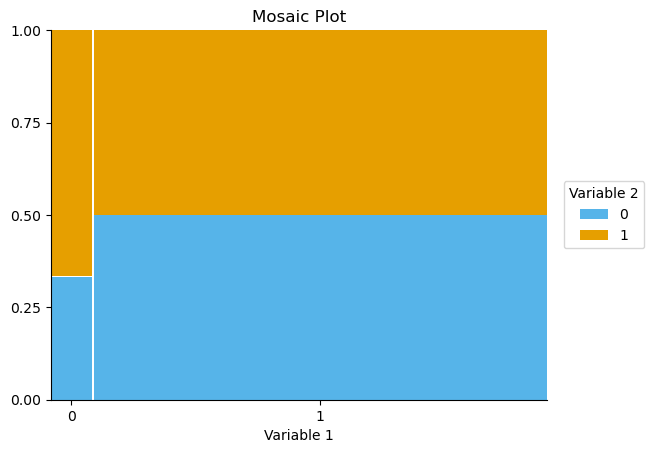

In [2]:
np.random.seed(7)
X, Y = RV(Bernoulli(p=0.9) * Bernoulli(p=0.5))
skewed = (X & Y).sim(500)

skewed.plot(type="mosaic", suggest=False)

## Asking for the other one

Two categories is well inside mosaic territory, so asking for a stacked bar
here gets you the mosaic anyway -- with a line telling you so. Nothing is
refused; you just get the plot that fits.

Your data has 2x2 categories, so the appropriate plot would be a Mosaic Plot. Showing that instead.


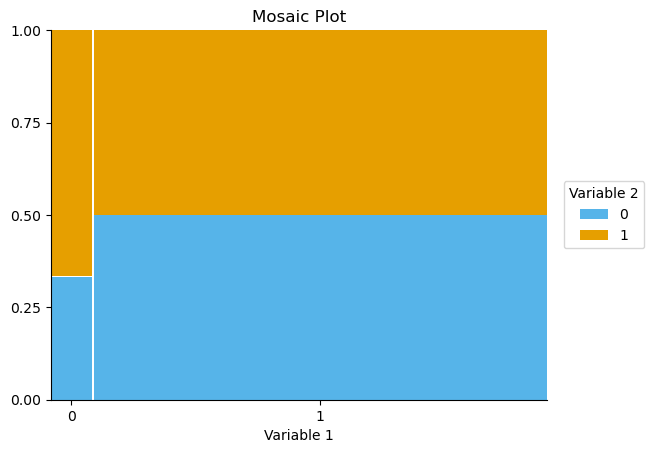

In [3]:
skewed.plot(type="stackedbar", suggest=False)   # asked for a stacked bar, gets a mosaic

## The category count decides

A mosaic makes each column as wide as its category is common -- informative
with a few categories, but past about four the rarer columns become slivers
you cannot compare. So beyond that point, asking for a mosaic gets you a
**stacked bar**, and it says so.

Here `x` is `Binomial(6, 0.3)`, so it has 7 categories (0 through 6):

Your data has 7x2 categories, so the appropriate plot would be a Stacked Bar Plot. Showing that instead.


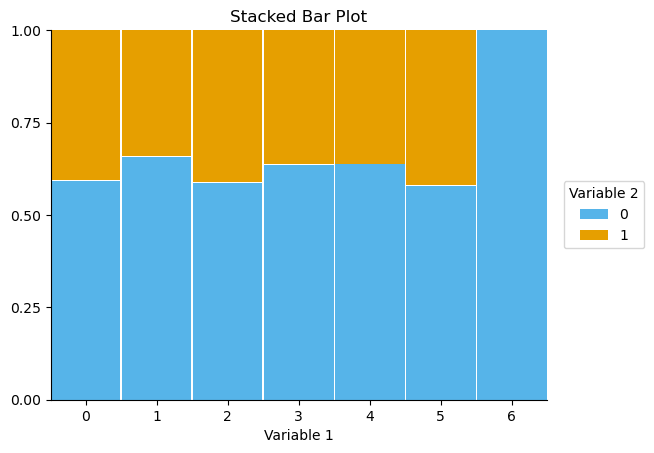

In [4]:
np.random.seed(3)
Xm, Ym = RV(Binomial(n=6, p=0.3) * Bernoulli(p=0.4))
many = (Xm & Ym).sim(1500)

many.plot(type="mosaic", suggest=False)   # asked for a mosaic, gets a stacked bar

Note the title: **Stacked Bar Plot**, because that is what was drawn. Every
column is the same width, so even the rarest category is readable -- which is
exactly what a mosaic could not manage here.

Asking for it by name on this data gives the identical plot, with no message,
because now it is the one that fits:

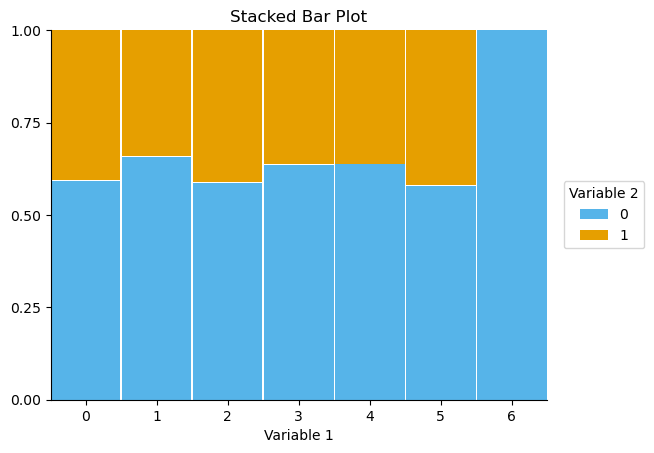

In [5]:
many.plot(type="stackedbar", suggest=False)

## Every column fills the axis

A column that is missing one of the y categories still runs from 0 to 1. (It
used to stop slightly short, leaving a thin blank strip where the absent
category's gap had been reserved.)

Below, `y` is always 0 when `x` is 0, so that column has only one segment:

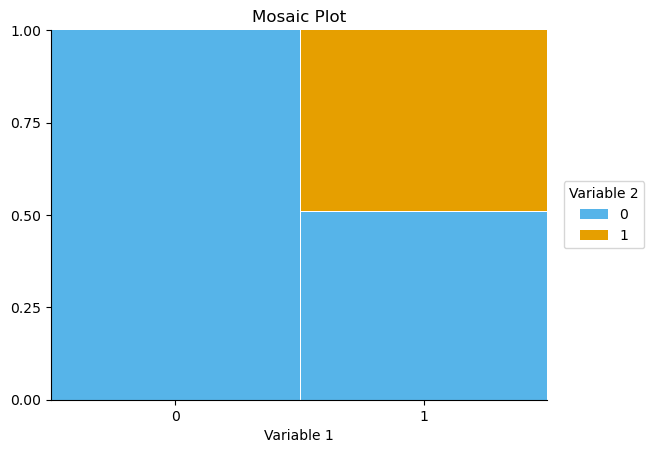

In [6]:
np.random.seed(11)
Xz = RV(Bernoulli(p=0.5))
Yz = Xz.apply(lambda v: int(v) * np.random.binomial(1, 0.5))
(Xz & Yz).sim(600).plot(type="mosaic", suggest=False)

## Two of these can't share one plot

Each type divides up the whole plot area for its own data, so a second one
would completely cover the first. That is refused rather than drawn:

ValueError: Overlaying a mosaic or stacked bar plot with another plot won't work -- each one fills the whole plot area, so they would cover each other up. Please run them separately (one .plot() per cell), or try a different plot type.


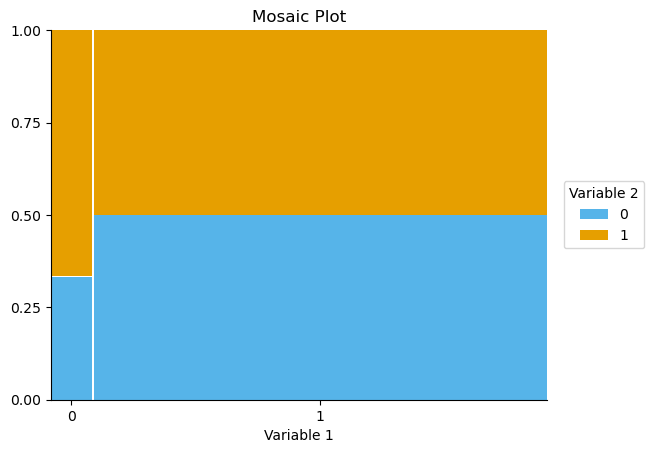

In [7]:
skewed.plot(type="mosaic", suggest=False)
try:
    skewed.plot(type="stackedbar", suggest=False)
except ValueError as e:
    print("ValueError:", e)

## The removed keywords

Both old keywords raise a message naming what to use instead, rather than
failing somewhere deep inside matplotlib:

In [8]:
for bad in [{"equal_width": True}, {"marginal_column": True}]:
    try:
        skewed.plot(type="mosaic", suggest=False, **bad)
    except ValueError as e:
        print(f"{list(bad)[0]}= ->", e, end="\n\n")

equal_width= -> equal_width= is no longer a plotting argument: the two column widths are now separate plot types. Use type='stackedbar' for equal-width columns, or type='mosaic' for widths proportional to how often each category occurred.

marginal_column= -> marginal_column= is no longer a plotting argument. A mosaic or stacked bar plot now names its categories with a legend instead of an extra column. To see one variable's overall distribution on its own, plot that variable by itself.



<Figure size 640x480 with 0 Axes>